# Exercise 1

In [29]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_excel("Impvols_SPX_AMZN.xlsx")

amzn_S = 231
spx_S = 6600
spx_d = 0.013
amzn_d = 0.
r = 0.048
T = 105./365.
rho = 0.5
n = 10000

#BS call prices
def BS(T, S, k, d, r, v):
    d1 = (np.log(S/k) +(r - d + 0.5*v**2)*T)/(v*np.sqrt(T))
    d2 = d1 - v*np.sqrt(T)
    return S*np.exp(-d*T)*st.norm.cdf(d1) - k*np.exp(-r*T)*st.norm.cdf(d2)


df["C_spx"] = df.apply(lambda row: BS(T, spx_S, row["spx_strikes"], spx_d, r, row["spx implied vols"]), axis=1)
df["C_amzn"] = df.apply(lambda row: BS(T, amzn_S, row["amzn_strikes"], amzn_d, r, row["amzn implied vols"]), axis=1)


#drop nan 
df_amzn = df[['amzn_strikes', 'amzn implied vols', 'C_amzn']].dropna()
df_spx = df[['spx_strikes', 'spx implied vols', 'C_spx']].dropna()

df_amzn.rename(columns = {'amzn_strikes':'K', 'amzn implied vols': 'IV', 'C_amzn': 'C'}, inplace = True)
df_spx.rename(columns = {'spx_strikes':'K', 'spx implied vols': 'IV', 'C_spx': 'C'}, inplace = True)

#sort by K for differentiation
df_amzn.sort_values(by = 'K', inplace = True)
df_spx.sort_values(by = 'K', inplace = True)

#CDF 
df_spx["PHI"] = 1 + np.exp(r*T)*(df_spx["C"].shift(-1) - df_spx["C"]) / (df_spx["K"].shift(-1) - df_spx["K"])
df_amzn["PHI"] = 1 + np.exp(r*T)*(df_amzn["C"].shift(-1) - df_amzn["C"]) / (df_amzn["K"].shift(-1) - df_amzn["K"])

In [30]:
df_spx.head() 

,K,IV,C,PHI
1,3802.0,0.460000,2830.279433,0.000991
2,3851.0,0.451075,2781.999291,0.003970
3,3900.0,0.443954,2733.863123,0.005528
4,3949.0,0.437649,2685.802219,0.006334
5,3999.0,0.431531,2636.800219,0.006348


Text(0.5, 1.0, 'S&P Index Empirical CDF')

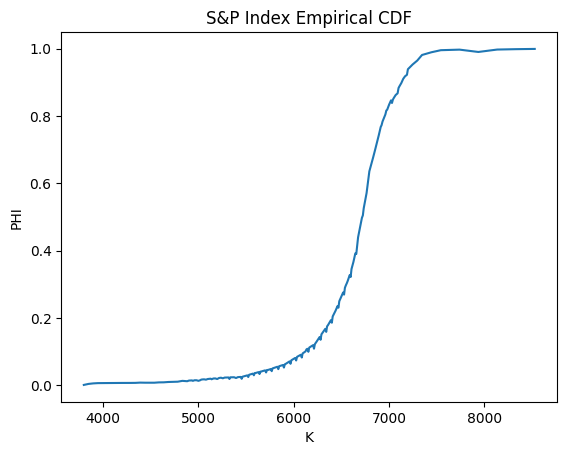

In [31]:
fig, ax = plt.subplots()
ax = sns.lineplot(data = df_spx,x ='K', y ='PHI')
ax.set_title('S&P Index Empirical CDF')

In [32]:
df_amzn.head()

,K,IV,C,PHI
1,110.74,0.610300,121.973479,-0.001649
2,111.68,0.603335,121.044841,-0.000100
3,112.63,0.596944,120.107775,0.000978
4,113.57,0.591072,119.181573,0.002277
5,114.52,0.585658,118.246734,0.003299


Text(0.5, 1.0, 'Amazon Stock Price Empirical CDF')

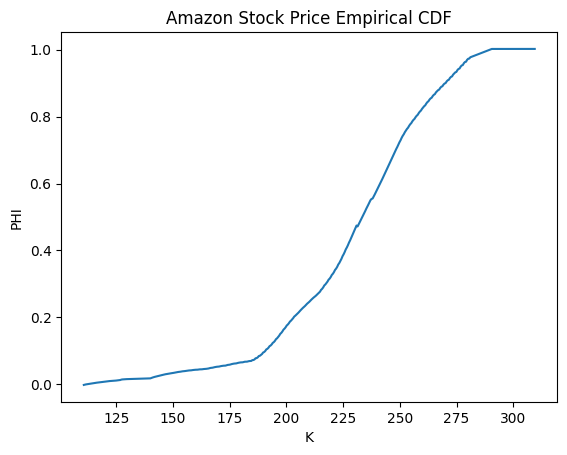

In [33]:

fig, ax = plt.subplots()
ax = sns.lineplot(data = df_amzn,x ='K', y ='PHI')
ax.set_title('Amazon Stock Price Empirical CDF')


In [34]:


#CDF inv by finding min K such that phi(K) >= x
def phi_inv(x, df):
    K = df[df['PHI'] >= x]['K'].values
    if len(K)!= 0:
        return K[0]
    #return max of K if none 
    return df['K'].max()


mu = [0,0]
cov = [[1, 0.5], [0.5, 1]]

prices = []
X = np.random.multivariate_normal(mu, cov, n)
for x1, x2 in X:
    a = st.norm.cdf(x1)
    b = st.norm.cdf(x2)
    S_amzn = phi_inv(a, df_amzn)
    S_spx = phi_inv(b, df_spx)
    prices.append(max(0., S_spx/spx_S - S_amzn/amzn_S)*np.exp(-r*T))


avg_price = sum(prices)/len(prices)
s = np.sqrt(sum((p - avg_price)**2 for p in prices)/(len(prices) - 1))
SE = s/np.sqrt(len(prices))

print(f"The expected price is {avg_price:.4f}, with a standard error of {SE:.4f}")




The expected price is 0.0540, with a standard error of 0.0009


# Exercise 2

In [40]:
U = st.uniform.rvs(size = 10000)
prices = []

for u in U:
    S_amzn = phi_inv(u, df_amzn)
    prices.append(max(0., 218**2 - S_amzn**2)*np.exp(-r*T))


avg_price = sum(prices)/len(prices)
s = np.sqrt(sum((p - avg_price)**2 for p in prices)/(len(prices) - 1))
SE = s/np.sqrt(len(prices))

print(f"The expected price is {avg_price:.3f}, with a standard error of {SE:.3f}")




The expected price is 3190.678, with a standard error of 67.499
